In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from model import model_eship, WORKER, ENTREPRENEUR

# Entrepreneurship, saving, and credit constraints

## The full model

A household enters period $t$ with cash-on-hand $M_t$, entrepreneurial human capital $h_t$, and current occupation $st_t\in\{\mathbb W,\mathbb E\}$. It chooses consumption $c_t$ and next period's occupation $d_t$:

$$V_t(M_t,h_t,st_t)=\max_{\substack{d_t\in\{\mathbb W,\mathbb E\}\\0\leq c_t\leq M_t-F(st_t,d_t)}}\left\{u(c_t)+\beta E_tV_{t+1}(M_{t+1},h_{t+1},d_t)\right\}.$$

Saving and the state transitions are

$$A_t=M_t-c_t-F(st_t,d_t),\qquad M_{t+1}=RA_t+y_{t+1},\qquad h_{t+1}=\gamma h_t+\Delta(st_t),$$

$$F(st_t,d_t)=F^{entry}\mathbf 1\{st_t=\mathbb W,d_t=\mathbb E\}+F^{exit}\mathbf 1\{st_t=\mathbb E,d_t=\mathbb W\},$$

$$y_{t+1}=\begin{cases}w\epsilon^W_{t+1},&d_t=\mathbb W,\\ \pi(h_{t+1},RA_t,\epsilon^E_{t+1}),&d_t=\mathbb E.\end{cases}$$

For an entrepreneur, capital is chosen before the productivity shock and is static conditional on saving:

$$k^*_{t+1}=\arg\max_{0\leq k\leq\lambda RA_t}\left\{\theta k^{\alpha}h_{t+1}^{\alpha_h}-rk\right\},\qquad \pi_{t+1}=\theta(k^*_{t+1})^{\alpha}h_{t+1}^{\alpha_h}\epsilon^E_{t+1}-rk^*_{t+1}.$$

Thus occupation and saving are dynamic choices, while business capital is nested as a static choice.

### Simplification used here

To expose the DC-EGM mechanics, this notebook sets $h_t\equiv1$. Human capital is left as an extension: it requires interpolation in both $(M_{t+1},h_{t+1})$ and reinterpolation of the occupation-specific endogenous grids onto a common $(M,h)$ grid before taking the discrete upper envelope.

The code defines $a_t\equiv RA_t$. Consequently it writes

$$c_t=M_t-a_t/R-F(st_t,d_t),\qquad M_{t+1}=a_t+y_{t+1}.$$

With $h=1$, $k^*(a)=\min\{\lambda a,(\alpha\theta/r)^{1/(1-\alpha)}\}$ and entrepreneurial income is $\theta k^*(a)^\alpha\epsilon^E-rk^*(a)$. This is the transition implemented in `egm.transition`.

### Baseline parameterization

| Parameter | Value | Meaning |
|---|---:|---|
| $T$, ages | 35, 25--59 | finite lifecycle and terminal age |
| $\beta$ | 0.96 | discount factor |
| $R=1+r$ | 1.04 | gross liquid return ($r=0.04$) |
| $\rho$ | 1.50 | CRRA coefficient |
| $w$ | 1.00 | mean worker income |
| $\sigma_W$ | 0.10 | standard deviation of the worker-income shock |
| $\theta$, $\alpha$ | 0.80, 0.33 | business productivity and capital elasticity |
| $\sigma_E$ | 0.30 | standard deviation of uninsurable business risk |
| $\lambda$ | 1.00 | collateral multiplier: no external business finance |
| $F^{entry}$, $F^{exit}$ | 0.20, 0 | switching costs |
| $\sigma_\eta$ | 0 | scale of iid extreme-value taste shocks |

Both income shocks are iid, mutually independent, positive mean-one lognormal shocks. Expectations use five-point Gauss--Hermite quadrature. Initial cash is lognormal with mean 1.6 and log standard deviation 0.55; everyone initially works. In the terminal period the household consumes all cash. The economic calibration is thesis-inspired rather than a replication: in particular, $\beta=0.96$ generates enough worker saving to make lifecycle entry visible.

Numerical settings are $N_M=240$, $N_a=220$, $M_{max}=a_{max}=14$, 20,000 simulated households, and seed 2026.

## 1. Solve and simulate the baseline

The class follows the exercise workflow: `setup`, `create_grids`, `solve`, and `simulate`. Economic primitives can be changed between `setup` and `create_grids`.

In [2]:
model = model_eship()
model.create_grids()
model.solve()
model.simulate()
par, sol, sim = model.par, model.sol, model.sim
print(f'Entries: {sim.entry.sum():,}; exits: {sim.exit.sum():,}')
print(f'Peak entrepreneur share: {np.mean(sim.z, axis=1).max():.1%}')

Entries: 3,587; exits: 3,587
Peak entrepreneur share: 17.9%


## 2. Why the problem is numerically nasty---and where DC-EGM enters

There are several sources of kinks: the borrowing constraint, the collateral constraint, the point where collateral stops binding, and the crossing of occupational values. Moreover, future occupational thresholds enter today's continuation values. Backward induction therefore creates **secondary kinks** and can make a choice-specific endogenous grid fold back on itself. Smooth global approximations are poorly suited to this geometry. Expectations may smooth some inherited kinks, but they do not generally restore global concavity.

Conditional on $d_t$, DC-EGM evaluates the Euler equation on the $a_t$ grid,

$$u'(c_t)=\beta R E_t\left[V_{M,t+1}(M_{t+1},d_t)\frac{\partial M_{t+1}}{\partial a_t}\right],$$

and obtains endogenous points $(M_t,c_t)$. The algorithm then has three distinct steps:

$$\text{EGM conditional on occupation}\;\longrightarrow\;\text{upper envelope within each branch}\;\longrightarrow\;\max\{v_t^W,v_t^E\}.$$

The within-branch envelope resolves folds and secondary kinks; the final comparison locates the discrete occupational threshold.

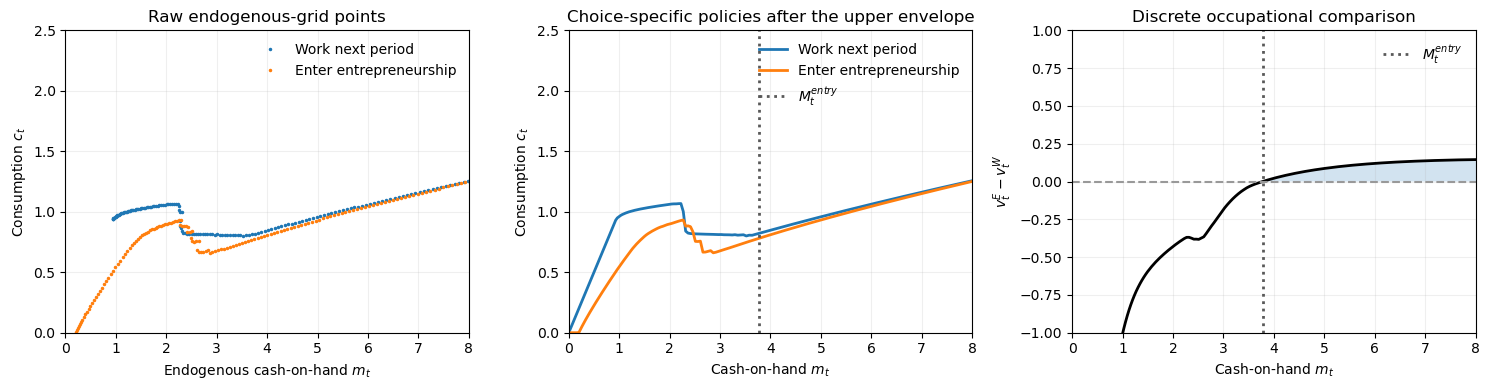

In [3]:
t, z = 0, WORKER
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for d, label in [(WORKER, 'Work next period'), (ENTREPRENEUR, 'Enter entrepreneurship')]:
    axes[0].plot(sol.m_endo[t,z,d], sol.c_endo[t,z,d], '.', ms=3, label=label)
    axes[1].plot(par.grid_m, sol.c_choice[t,z,d], lw=2, label=label)
axes[0].set(title='Raw endogenous-grid points', xlabel='Endogenous cash-on-hand $m_t$', ylabel='Consumption $c_t$', xlim=(0,8), ylim=(0,2.5))
axes[1].set(title='Choice-specific policies after the upper envelope', xlabel='Cash-on-hand $m_t$', ylabel='Consumption $c_t$', xlim=(0,8), ylim=(0,2.5))
entry_threshold = model.threshold(t, z)
for ax in axes[1:]: ax.axvline(entry_threshold, color='0.35', ls=':', lw=2, label=r'$M_t^{entry}$')
value_difference = sol.v_choice[t,z,ENTREPRENEUR]-sol.v_choice[t,z,WORKER]
axes[2].plot(par.grid_m, value_difference, color='black', lw=2)
axes[2].axhline(0, color='0.6', ls='--'); axes[2].fill_between(par.grid_m, 0, value_difference, where=value_difference>0, alpha=.2)
axes[2].set(title='Discrete occupational comparison', xlabel='Cash-on-hand $m_t$', ylabel='$v_t^E-v_t^W$', xlim=(0,8), ylim=(-1,1))
for ax in axes: ax.grid(alpha=.2)
for ax in axes: ax.legend(frameon=False)
plt.tight_layout()

**What the figure shows.** The raw entrepreneurial grid is not monotone: high marginal returns to collateral at low wealth interact with future occupation choices. Sorting these points and interpolating once would connect the wrong pieces. The within-branch upper envelope retains the best feasible segment at every $M_t$. Only after that operation is it valid to compare $v_t^E$ and $v_t^W$; entrepreneurship is selected where the value difference is positive. The dotted line marks $M_t^{entry}$, the primary kink generated by this discrete comparison. This is the central DC-EGM calculation.

## 3. The economic effect of an entry cost

Now solve the same model with $F^{entry}=0$. The entry cost shifts resources and the value of entrepreneurship, so it raises the cash level required to enter. It does not apply to someone who is already an entrepreneur. This creates hysteresis: the entry threshold exceeds the continuation threshold.

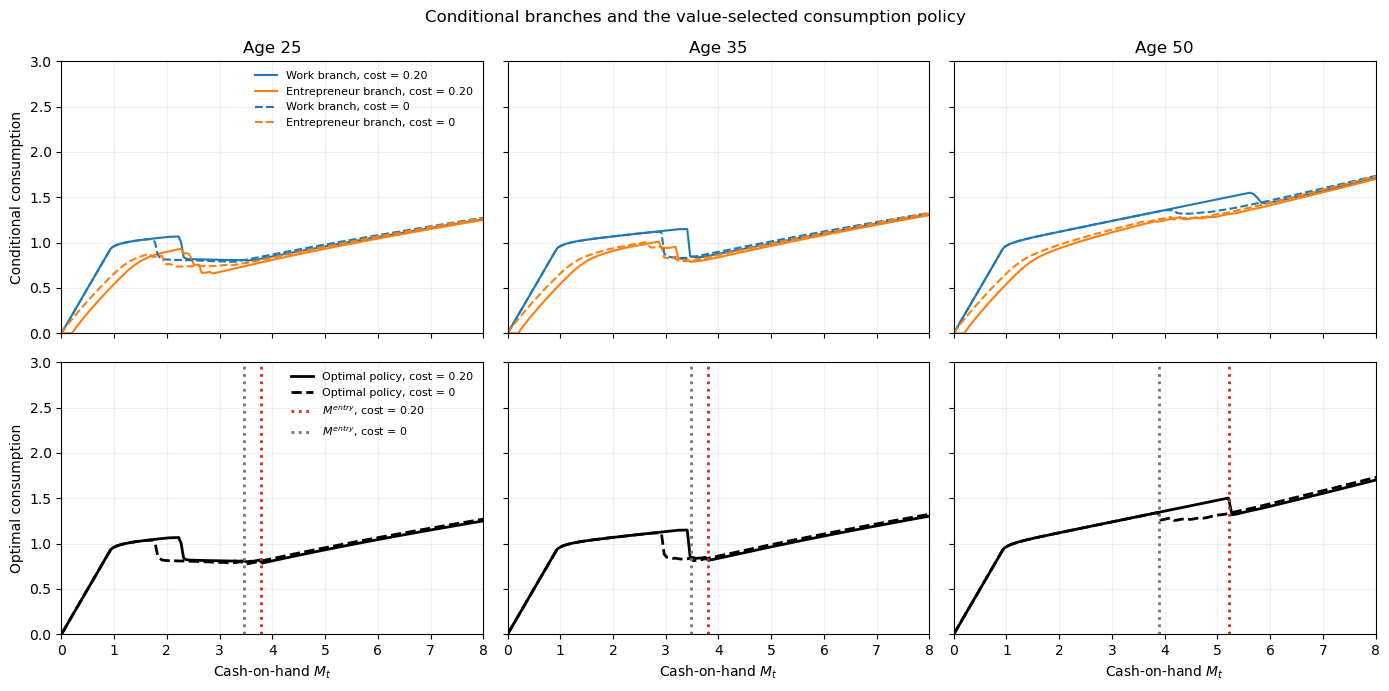

In [4]:
no_cost = model_eship()
no_cost.par.entry_cost = 0.0
no_cost.create_grids(); no_cost.solve(); no_cost.simulate()

ages = [25, 35, 50]
fig, axes = plt.subplots(2, len(ages), figsize=(14, 7), sharex='col', sharey='row')
for j, age in enumerate(ages):
    t = age-par.age_min

    # Conditional policies: solid = entry cost 0.20; dashed = no entry cost.
    axes[0,j].plot(par.grid_m, sol.c_choice[t,WORKER,WORKER], color='C0', label='Work branch, cost = 0.20')
    axes[0,j].plot(par.grid_m, sol.c_choice[t,WORKER,ENTREPRENEUR], color='C1', label='Entrepreneur branch, cost = 0.20')
    axes[0,j].plot(par.grid_m, no_cost.sol.c_choice[t,WORKER,WORKER], '--', color='C0', label='Work branch, cost = 0')
    axes[0,j].plot(par.grid_m, no_cost.sol.c_choice[t,WORKER,ENTREPRENEUR], '--', color='C1', label='Entrepreneur branch, cost = 0')

    # Optimal policy selected by the upper envelope of values.
    axes[1,j].plot(par.grid_m, sol.c[t,WORKER], color='black', lw=2, label='Optimal policy, cost = 0.20')
    axes[1,j].plot(par.grid_m, no_cost.sol.c[t,WORKER], '--', color='black', lw=2, label='Optimal policy, cost = 0')
    axes[1,j].axvline(model.threshold(t,WORKER), color='C3', ls=':', lw=2, label=r'$M^{entry}$, cost = 0.20')
    axes[1,j].axvline(no_cost.threshold(t,WORKER), color='0.45', ls=':', lw=2, label=r'$M^{entry}$, cost = 0')

    axes[0,j].set(title=f'Age {age}', xlim=(0,8), ylim=(0,3)); axes[1,j].set(xlabel='Cash-on-hand $M_t$', xlim=(0,8), ylim=(0,3))
    axes[0,j].grid(alpha=.2); axes[1,j].grid(alpha=.2)
axes[0,0].set_ylabel('Conditional consumption')
axes[1,0].set_ylabel('Optimal consumption')
axes[0,0].legend(frameon=False, fontsize=8)
axes[1,0].legend(frameon=False, fontsize=8)
fig.suptitle('Conditional branches and the value-selected consumption policy')
plt.tight_layout()

**Interpretation.** The top row shows that entry costs also affect the work branch: working today avoids the cost today, but changes the value of entering later and therefore current saving. The large drops inside the conditional policies are secondary kinks associated with collateral regimes and anticipated future occupational choices. The bottom row selects consumption from whichever branch delivers the upper value envelope. Its dotted lines are the interpolated roots of $v_t^E-v_t^W=0$; the switch between branches is the primary kink.

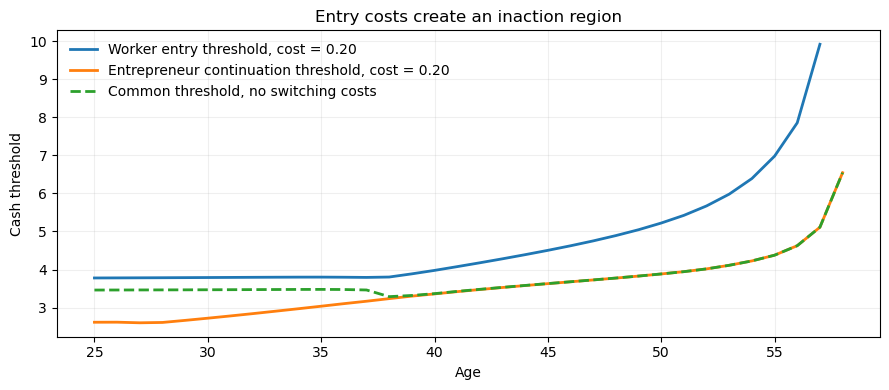

In [5]:
age = np.arange(par.T-1)+par.age_min
entry = np.array([model.threshold(t, WORKER) for t in range(par.T-1)])
continue_e = np.array([model.threshold(t, ENTREPRENEUR) for t in range(par.T-1)])
entry_free = np.array([no_cost.threshold(t, WORKER) for t in range(par.T-1)])
plt.figure(figsize=(9,4))
plt.plot(age, entry, label='Worker entry threshold, cost = 0.20', lw=2)
plt.plot(age, continue_e, label='Entrepreneur continuation threshold, cost = 0.20', lw=2)
plt.plot(age, entry_free, '--', label='Common threshold, no switching costs', lw=2)
plt.xlabel('Age'); plt.ylabel('Cash threshold'); plt.title('Entry costs create an inaction region')
plt.grid(alpha=.2); plt.legend(frameon=False); plt.tight_layout()

**Interpretation.** With no switching costs, current occupation has no payoff effect, so the worker-entry and entrepreneur-continuation thresholds coincide exactly. A positive entry cost raises the worker's entry threshold and opens an inaction region. A worker below the upper line remains a worker, while an existing entrepreneur above the lower line continues operating. Entry becomes progressively less attractive late in life because fewer periods remain over which to recover the fixed cost.

## 4. The collateral constraint

The baseline has $\lambda=1$: one unit of liquid wealth supports at most one unit of business capital. The next experiment raises $\lambda$ to 1.20, allowing a modest amount of external finance while holding preferences, technology, risks, and random draws fixed.

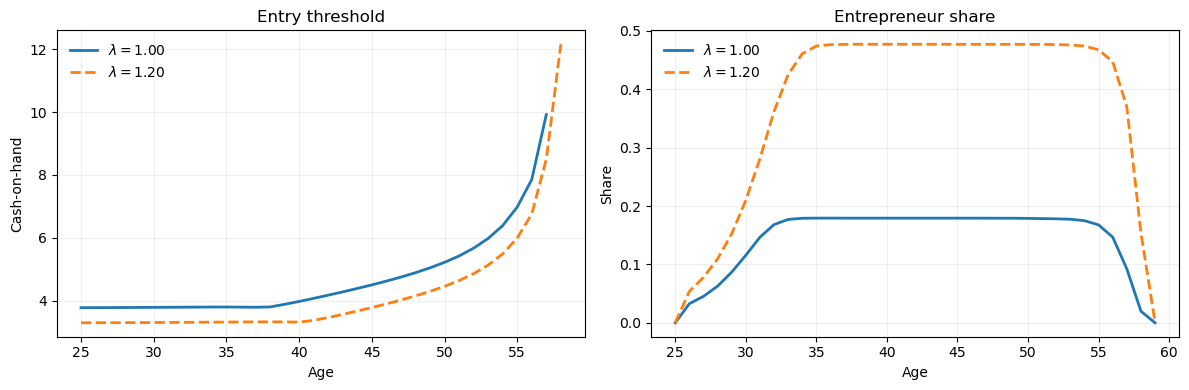

In [6]:
loose_credit = model_eship()
loose_credit.par.lambd = 1.20
loose_credit.create_grids(); loose_credit.solve(); loose_credit.simulate()
entry_loose = np.array([loose_credit.threshold(t, WORKER) for t in range(par.T-1)])

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(age, entry, label=r'$\lambda=1.00$', lw=2)
axes[0].plot(age, entry_loose, '--', label=r'$\lambda=1.20$', lw=2)
axes[0].set(title='Entry threshold', xlabel='Age', ylabel='Cash-on-hand')
sim_age = np.arange(par.T)+par.age_min
axes[1].plot(sim_age, np.mean(sim.z,axis=1), label=r'$\lambda=1.00$', lw=2)
axes[1].plot(sim_age, np.mean(loose_credit.sim.z,axis=1), '--', label=r'$\lambda=1.20$', lw=2)
axes[1].set(title='Entrepreneur share', xlabel='Age', ylabel='Share')
for ax in axes: ax.grid(alpha=.2); ax.legend(frameon=False)
plt.tight_layout()

**Interpretation.** Looser collateral raises the return to entrepreneurial saving at low wealth. It lowers the entry threshold and allows substantially more workers to finance a viable business. This is a dynamic credit-supply effect: finance changes not only business scale after entry, but also the occupational decision and the wealth at which entry becomes worthwhile.

## 5. Simulated entry and exit

The calibration is chosen to produce economic action without forcing transitions mechanically. Workers save and may cross the entry threshold after favorable wage histories. Business risk can move entrepreneurs across the continuation threshold, and the shrinking horizon eventually makes entry less attractive. Common random numbers make the comparison across entry costs cleaner.

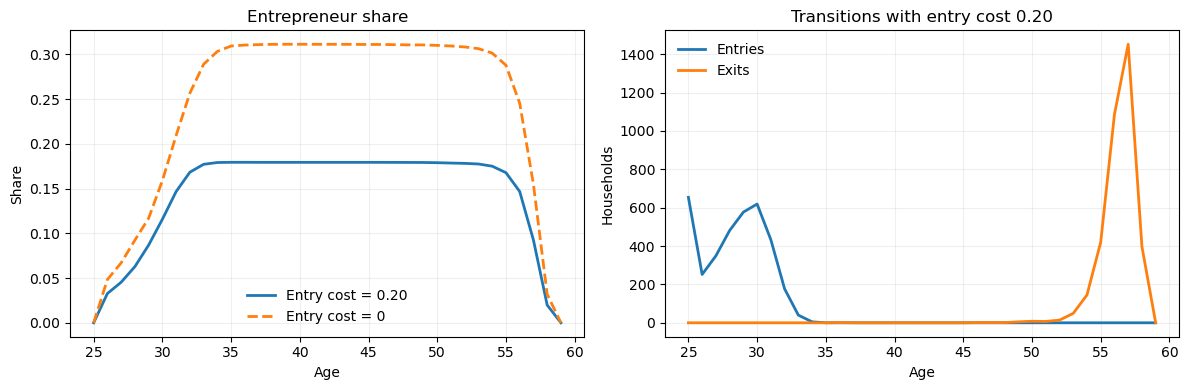

In [7]:
age = np.arange(par.T)+par.age_min
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(age, np.mean(sim.z,axis=1), label='Entry cost = 0.20', lw=2)
axes[0].plot(age, np.mean(no_cost.sim.z,axis=1), '--', label='Entry cost = 0', lw=2)
axes[0].set(title='Entrepreneur share', xlabel='Age', ylabel='Share')
axes[1].plot(age, sim.entry.sum(axis=1), label='Entries', lw=2)
axes[1].plot(age, sim.exit.sum(axis=1), label='Exits', lw=2)
axes[1].set(title='Transitions with entry cost 0.20', xlabel='Age', ylabel='Households')
for ax in axes: ax.grid(alpha=.2); ax.legend(frameon=False)
plt.tight_layout()

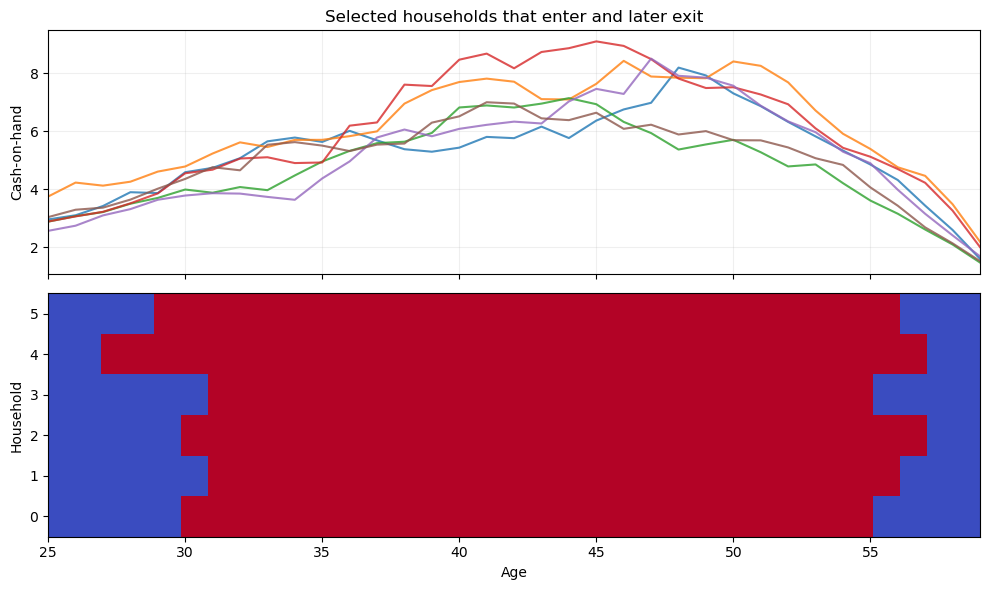

In [8]:
# Display a few households that both enter and exit.
both = np.flatnonzero(sim.entry.any(axis=0) & sim.exit.any(axis=0))[:6]
fig, axes = plt.subplots(2,1,figsize=(10,6),sharex=True)
for i in both: axes[0].plot(age,sim.m[:,i],alpha=.8)
axes[1].imshow(sim.z[:,both].T,aspect='auto',interpolation='nearest',extent=(age[0],age[-1],-.5,len(both)-.5),vmin=0,vmax=1,cmap='coolwarm')
axes[0].set(ylabel='Cash-on-hand',title='Selected households that enter and later exit'); axes[0].grid(alpha=.2)
axes[1].set(xlabel='Age',ylabel='Household',yticks=range(len(both))); plt.tight_layout()

**Interpretation.** Entry is not imposed at age 25: workers cross the threshold at different ages after accumulating wealth under different wage histories. Once inside, the lower continuation threshold makes entrepreneurship persistent, although adverse business shocks can still induce exit. The pronounced late-life exit wave partly reflects the finite terminal condition; it demonstrates the lifecycle mechanism but should not be read as a calibrated empirical retirement prediction.

## 6. Student parameter laboratory

Try changing one primitive in `model.par` before `create_grids()` and predict the result before solving:

- Raise `entry_cost`: what happens to entry timing and the entrepreneur share?
- Raise `lambd`: does looser collateral increase entry, business income, or both?
- Raise `sigma_e`: how does uninsurable business risk affect saving and occupational switching?
- Raise `rho`: how does greater risk aversion change exposure to entrepreneurship?
- Raise `beta`: do workers accumulate enough wealth to enter earlier?

Keep the seed fixed when comparing simulations.

## 7. Prepared extension: iid extreme-value taste shocks

The baseline sets `sigma_eta=0`, so occupation is selected by an exact maximum. A positive `sigma_eta` replaces the max with a log-sum and stores smooth choice probabilities in `sol.prob`. No other code changes are needed.

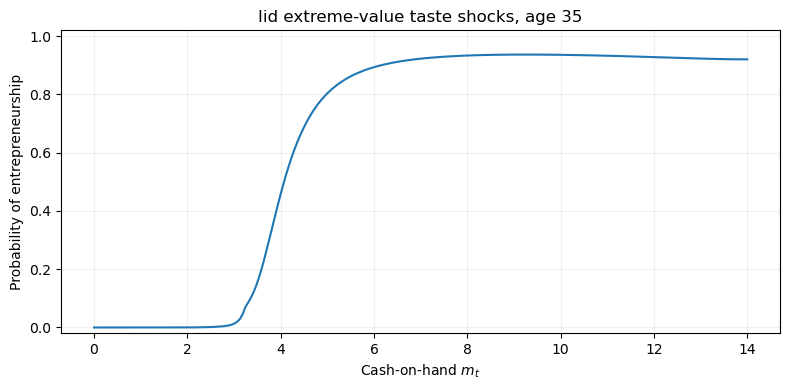

In [9]:
smooth = model_eship()
smooth.par.sigma_eta = 0.05
smooth.create_grids(); smooth.solve()
t = 10
plt.figure(figsize=(8,4))
plt.plot(smooth.par.grid_m, smooth.sol.prob[t,WORKER,ENTREPRENEUR])
plt.xlabel('Cash-on-hand $m_t$'); plt.ylabel('Probability of entrepreneurship')
plt.title(f'Iid extreme-value taste shocks, age {smooth.par.age_min+t}')
plt.ylim(-.02,1.02); plt.grid(alpha=.2); plt.tight_layout()

**Interpretation.** Taste shocks replace the sharp occupation threshold by a smooth probability. They smooth the outer discrete-choice comparison, but the underlying choice-specific problems still contain borrowing, collateral, and inherited policy kinks. DC-EGM therefore remains useful inside each branch.